In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd
df1=pd.read_csv("/content/i1.csv")
df2=pd.read_csv("/content/i2.csv")

In [11]:
df=df1.merge(df2,how="outer")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [12]:
df.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [14]:
df['Invoice No.'].nunique()

4925

In [15]:
df['Final Total'].sum()

np.float64(2397010.12)

In [16]:
a=df.groupby("Item Name")['Qty.'].sum().sort_values(ascending=False)[0:5]
a



,Qty.
Item Name,
Mineral Water,1672.0
Chicken Biriyani With Raitha And Gravy,1453.0
Butter Naan,1046.0
Romali Roti (1 No),822.0
Lemon Soda,722.0


<Axes: xlabel='Item Name', ylabel='Qty.'>

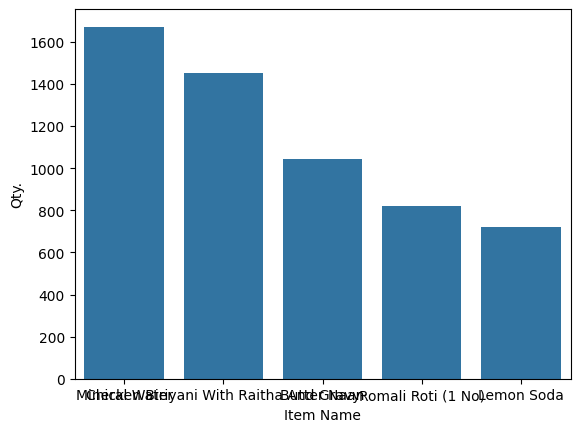

In [17]:
sns.barplot(a)

In [18]:
b=df.groupby("Item Name")['Final Total'].sum().sort_values(ascending=False)[0:5]
b

,Final Total
Item Name,
Chicken Biriyani With Raitha And Gravy,240730.96
Chicken Fried Rice,119347.20
Butter Naan,65387.74
Thandoor Chicken Half,53185.83
Paneer Butter Masala,49581.22


<Axes: xlabel='Item Name', ylabel='Final Total'>

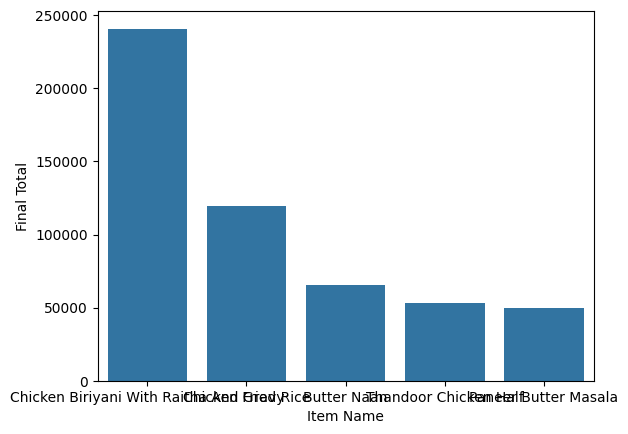

In [19]:
sns.barplot(b)

In [20]:
c=df[df['Date']=='2023-09-15']['Final Total']
c

,Final Total
15070,136.5
15071,178.5
15072,52.5
15073,31.5
15074,168.0
...,...
15216,136.5
15217,52.5
15218,21.0
15219,147.0


In [21]:
df[(df['Date']=="2023-09-15") & (df["Item Name"]=="Chicken Noodles")]['Qty.'].sum()

np.float64(7.0)

In [22]:
df[df['Final Total'] >= 2000]['Invoice No.']

,Invoice No.
1039,23827
4694,24987
6103,25427
6117,25434
11405,27210
14772,28126


In [23]:
j=df.groupby('Invoice No.')['Final Total'].sum()
j[j > 2000]

,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [24]:
e=df[df['Final Total']== 2887.50]['Invoice No.']
e

,Invoice No.
14772,28126


In [25]:
p=df[df['Invoice No.'] == 28145][['Final Total','Item Name','Qty.']].sum()
p

,0
Final Total,4078.68
Item Name,Butter Chicken GravyButter Chicken GravyButter...
Qty.,40.0


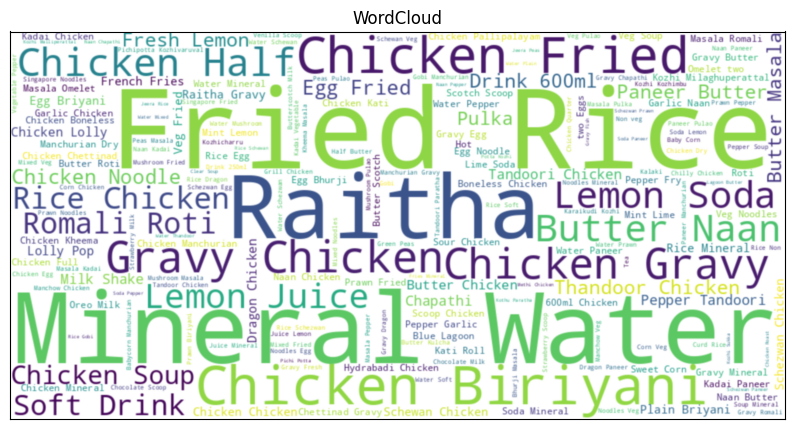

In [26]:
from wordcloud import WordCloud
text=" ".join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color="white",width=1000,height=500).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bicubic')
ax.set_title("WordCloud")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

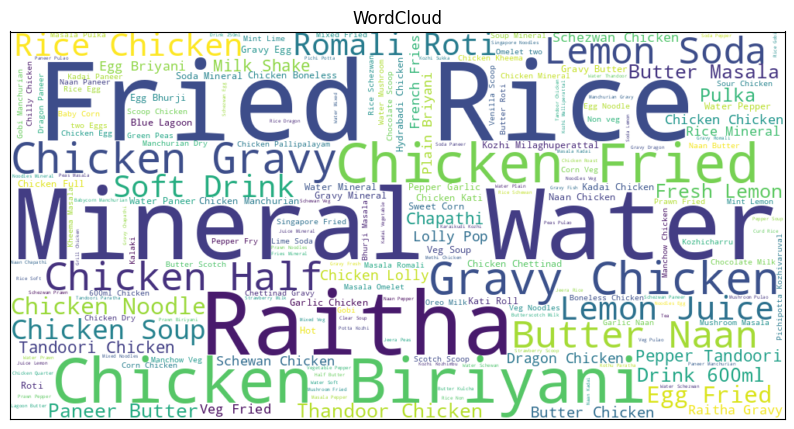

In [27]:
from wordcloud import WordCloud
text=" ".join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color="white",width=1000,height=500).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_title("WordCloud")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

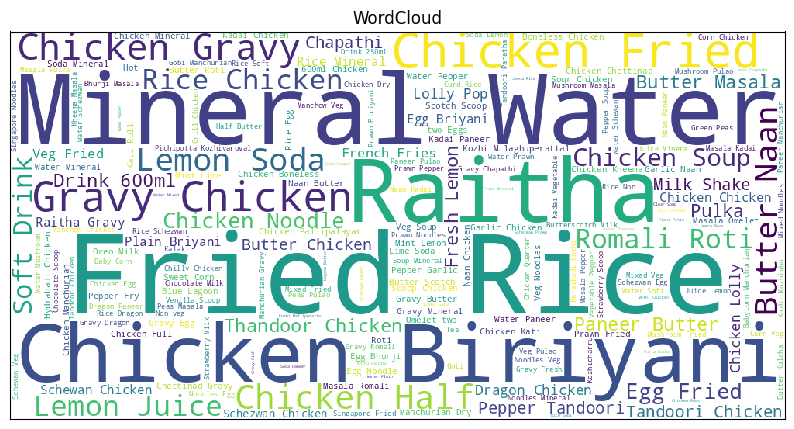

In [28]:
from wordcloud import WordCloud
text=" ".join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color="white",width=1000,height=500).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='nearest')
ax.set_title("WordCloud")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

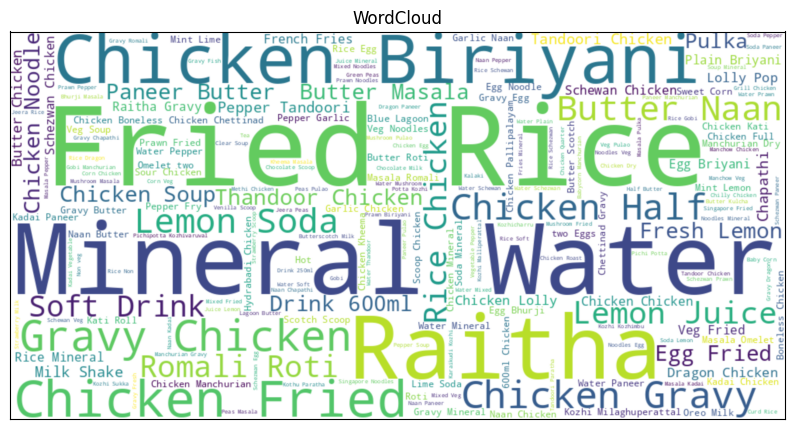

In [29]:
from wordcloud import WordCloud
text=" ".join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color="white",width=1000,height=500).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='quadric')
ax.set_title("WordCloud")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

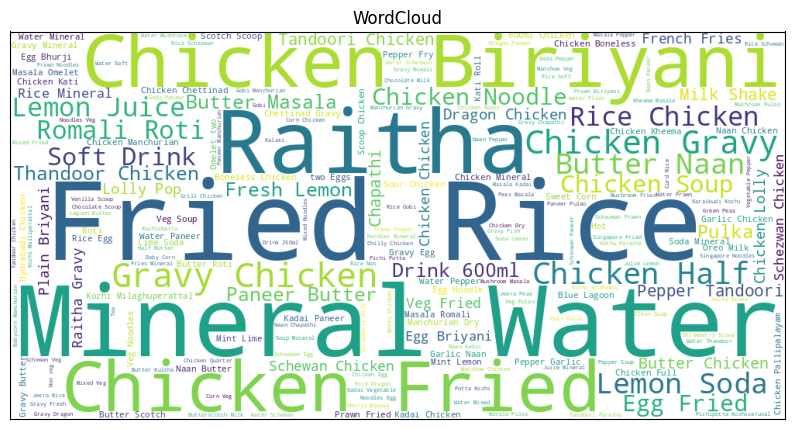

In [30]:
from wordcloud import WordCloud
text=" ".join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color="white",width=1000,height=500).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='antialiased')
ax.set_title("WordCloud")
ax.set_xticks([])
ax.set_yticks([])
plt.show()